# Evaluasi AI-1 (`bacaStruk`) — JEJAK

**Ini bukan notebook training.** Tidak ada model yang dilatih atau bobot yang diubah di sini.
Yang terjadi: kode produksi `bacaStruk` (`services/verifier/ai.ts`, memanggil Claude API,
zero-shot) dijalankan atas sampel struk dari dataset publik
[SROIE v2](https://www.kaggle.com/datasets/urbikn/sroie-datasetv2) (ICDAR 2019), lalu hasilnya
dibandingkan ke label ground-truth resmi dataset itu.

Notebook ini **tidak memanggil AI apa pun** — cuma membaca `results/hasil-eval.json` yang
sudah dihasilkan `run-eval.ts`. Buka-tutup/ubah tampilan di sini nol biaya token.

**Keterbatasan yang jujur perlu disebut di depan:** SROIE adalah struk scan rapi berbahasa
Inggris — bukan struk termal miring/pudar berbahasa Jepang/Korea/Mandarin/Thailand yang jadi
kasus tersulit JEJAK sesungguhnya (lihat `INSTRUKSI_STRUK` di `ai.ts`). Evaluasi ini membuktikan
*pipeline*-nya bekerja dan terukur — **bukan** klaim model ini sudah siap produksi.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_colwidth", 60)

with open(Path("results") / "hasil-eval.json") as f:
    hasil = json.load(f)

df = pd.json_normalize(hasil)
df = df.rename(columns={
    "file": "berkas",
    "groundTruth.company": "merchantAsli",
    "groundTruth.total": "totalAsli",
    "groundTruth.date": "tanggalAsli",
    "prediksi.merchant": "merchantPrediksi",
    "prediksi.nominal": "totalPrediksi",
    "prediksi.tanggal": "tanggalPrediksi",
    "prediksi.keyakinan": "keyakinan",
    "prediksi.sumber": "sumber",
})
n = len(df)
print(f"{n} struk dimuat dari hasil-eval.json")

8 struk dimuat dari hasil-eval.json


## Hasil per struk

Hijau = cocok dengan label ground-truth SROIE, merah = tidak.

In [2]:
kolom_tampil = ["berkas", "merchantAsli", "merchantPrediksi", "cocokMerchant",
                "totalAsli", "totalPrediksi", "cocokTotal",
                "tanggalAsli", "tanggalPrediksi", "cocokTanggal", "keyakinan"]

def warnai_bool(v):
    if v is True:
        return "background-color: #16a34a; color: white"
    if v is False:
        return "background-color: #dc2626; color: white"
    return ""

(df[kolom_tampil]
   .style
   .map(warnai_bool, subset=["cocokMerchant", "cocokTotal", "cocokTanggal"])
   .format({"keyakinan": "{:.2f}"})
   .set_caption(f"Hasil bacaStruk vs label SROIE (n={n})"))

,berkas,merchantAsli,merchantPrediksi,cocokMerchant,totalAsli,totalPrediksi,cocokTotal,tanggalAsli,tanggalPrediksi,cocokTanggal,keyakinan
0,X00016469670.jpg,OJC MARKETING SDN BHD,OJC MARKETING SDN BHD,True,193.00,193.000000,True,15/01/2019,2019-01-15,True,0.95
1,X00016469671.jpg,OJC MARKETING SDN BHD,OJC MARKETING SDN BHD,True,170.00,170.000000,True,02/01/2019,2019-01-02,True,0.90
2,X51005200931.jpg,PERNIAGAAN ZHENG HUI,PERNIAGAAN ZHENG HUI,True,436.20,436.200000,True,09/02/2018,2018-02-09,True,0.90
3,X51005230605.jpg,PETRON BKT LANJAN SB,PETRON BKT LANJAN SB,True,4.90,4.900000,True,01/02/2018,2018-02-01,True,0.90
4,X51005230616.jpg,GERBANG ALAF RESTAURANTS SDN BHD,McDonald's Petronas Taman Melati DT,False,38.90,38.900000,True,18/01/2018,2018-01-18,True,0.60
5,X51005230621.jpg,SIN LIANHAP SDN BHD,SIN LIANHAP SDN BHD,True,7.30,7.300000,True,05/02/2018,2018-02-05,True,0.90
6,X51005230648.jpg,CROSS CHANNEL NETWORK SDN. BHD.,CROSS CHANNEL NETWORK SDN. BHD.,True,6.35,6.350000,True,29/01/2018,2018-01-29,True,0.90
7,X51005230657.jpg,CROSS CHANNEL NETWORK SDN. BHD.,CROSS CHANNEL NETWORK SDN. BHD.,True,7.95,7.950000,True,31/12/2017,2017-12-31,True,0.55


## Ringkasan angka

In [3]:
ringkasan = pd.Series({
    "Struk diuji": n,
    "Akurasi total (%)": round(df["cocokTotal"].mean() * 100, 1),
    "Akurasi tanggal (%)": round(df["cocokTanggal"].mean() * 100, 1),
    "Akurasi merchant (%)": round(df["cocokMerchant"].mean() * 100, 1),
    "Rata-rata keyakinan": round(df["keyakinan"].mean(), 3),
    "Semua panggilan mode": ", ".join(df["sumber"].unique()),
    "Perkiraan total biaya (USD)": round(df["perkiraanBiayaUsd"].sum(), 4),
})
ringkasan

Struk diuji                        8
Akurasi total (%)              100.0
Akurasi tanggal (%)            100.0
Akurasi merchant (%)            87.5
Rata-rata keyakinan            0.825
Semua panggilan mode              ai
Perkiraan total biaya (USD)        0
dtype: object

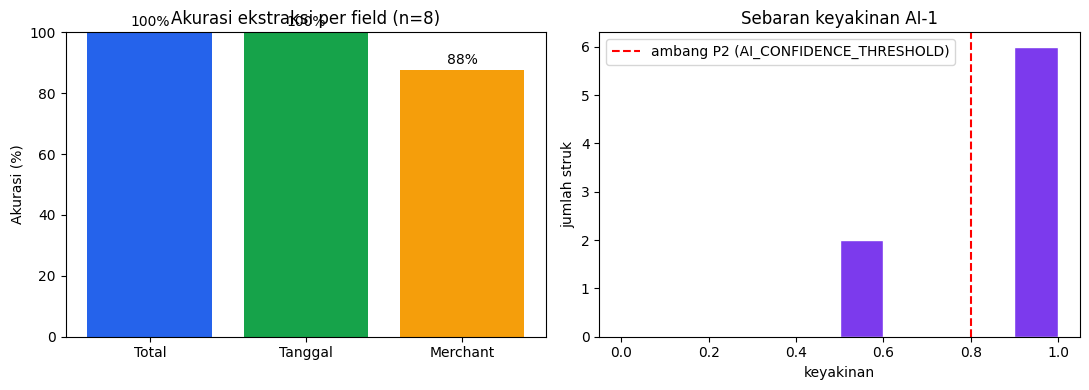

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

metrik = ["cocokTotal", "cocokTanggal", "cocokMerchant"]
label_metrik = ["Total", "Tanggal", "Merchant"]
akurasi = [df[m].mean() * 100 for m in metrik]
axes[0].bar(label_metrik, akurasi, color=["#2563eb", "#16a34a", "#f59e0b"])
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Akurasi (%)")
axes[0].set_title(f"Akurasi ekstraksi per field (n={n})")
for i, v in enumerate(akurasi):
    axes[0].text(i, v + 2, f"{v:.0f}%", ha="center")

axes[1].hist(df["keyakinan"], bins=10, range=(0, 1), color="#7c3aed", edgecolor="white")
axes[1].axvline(0.80, color="red", linestyle="--", label="ambang P2 (AI_CONFIDENCE_THRESHOLD)")
axes[1].set_xlabel("keyakinan")
axes[1].set_ylabel("jumlah struk")
axes[1].set_title("Sebaran keyakinan AI-1")
axes[1].legend()

plt.tight_layout()
plt.show()

## Bukti visual: struk asli vs bacaan AI

Bukan cuma angka di tabel — ini foto strukmu sendiri, berdampingan dengan apa yang
`bacaStruk` baca. Border hijau = total cocok dengan label, merah = tidak.

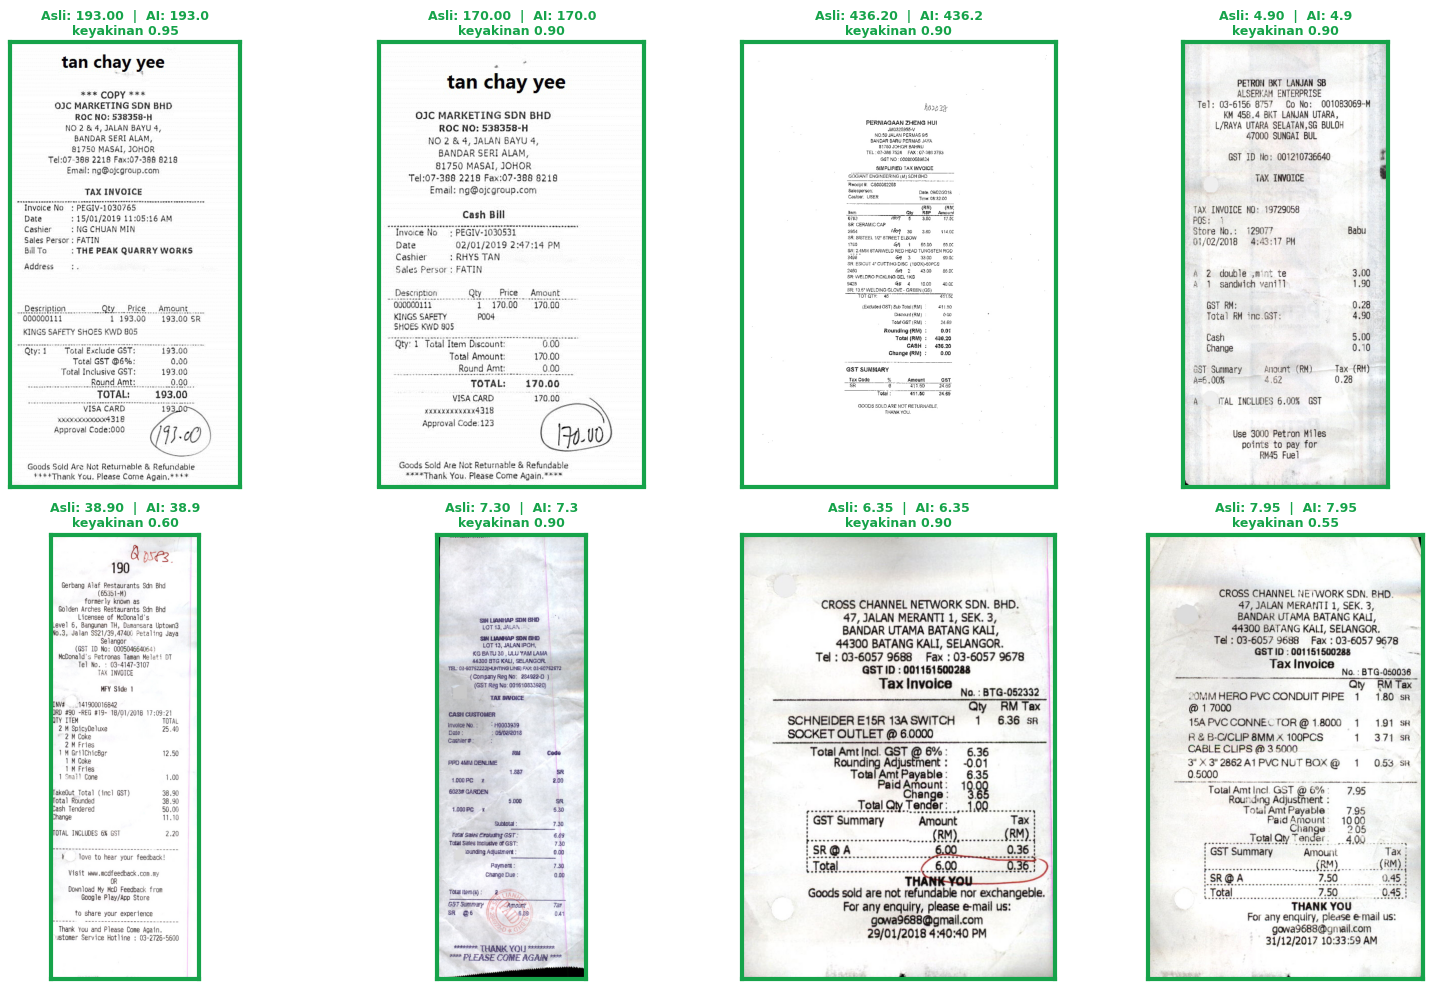

In [5]:
DIR_GAMBAR = Path("../../Data/SROIE2019/test/img")

kolom = 4
baris = -(-n // kolom)
fig, axes = plt.subplots(baris, kolom, figsize=(4 * kolom, 5 * baris))
axes = axes.flatten() if n > 1 else [axes]

for ax, (_, row) in zip(axes, df.iterrows()):
    path_gambar = DIR_GAMBAR / row["berkas"]
    warna = "#16a34a" if row["cocokTotal"] else "#dc2626"
    if path_gambar.exists():
        img = Image.open(path_gambar)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "gambar tidak\nditemukan lokal", ha="center", va="center")
    ax.set_title(
        f"Asli: {row['totalAsli']}  |  AI: {row['totalPrediksi']}\nkeyakinan {row['keyakinan']:.2f}",
        fontsize=9, color=warna, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(warna)
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Seberapa siap model ini? (jujur, bukan cuma klaim)

In [6]:
import math

def wilson_interval(k, n, z=1.96):
    """Interval kepercayaan 95% Wilson score — cocok untuk sampel kecil,
    tidak seperti interval normal biasa yang bisa keluar dari rentang [0,1]."""
    if n == 0:
        return (0.0, 0.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    margin = z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return (max(0, (center - margin) / denom), min(1, (center + margin) / denom))

for label, kolom in [("Total", "cocokTotal"), ("Tanggal", "cocokTanggal"), ("Merchant", "cocokMerchant")]:
    k = int(df[kolom].sum())
    lo, hi = wilson_interval(k, n)
    print(f"{label:10s}: {k}/{n} teramati  →  akurasi SEBENARNYA kemungkinan ada di [{lo*100:.0f}%, {hi*100:.0f}%] (95% keyakinan)")

Total     : 8/8 teramati  →  akurasi SEBENARNYA kemungkinan ada di [68%, 100%] (95% keyakinan)
Tanggal   : 8/8 teramati  →  akurasi SEBENARNYA kemungkinan ada di [68%, 100%] (95% keyakinan)
Merchant  : 7/8 teramati  →  akurasi SEBENARNYA kemungkinan ada di [53%, 98%] (95% keyakinan)


**Baca angkanya seperti ini:** walau tabel di atas menunjukkan 100% pada beberapa kolom,
dengan sampel sekecil ini interval Wilson-nya masih lebar — akurasi sebenarnya bisa saja
jauh di bawah 100% dan kita belum akan tahu. Ini bukan cacat metodologi, ini fakta
matematis soal sampel kecil, dan sengaja ditampilkan di sini biar tidak ada yang membaca
"100%" di tabel sebagai jaminan.

**Kesimpulan jujur:**
- Pipeline (`gambar.ts` → `bacaStruk` → `decision.ts`) terbukti **berfungsi** end-to-end
  dengan panggilan API sungguhan, bukan mock.
- Hasil pada sampel ini **menjanjikan**, bukan konklusif — n masih kecil.
- SROIE **tidak** menguji kasus tersulit JEJAK (struk termal multibahasa). Klaim "model
  ini sudah paten/siap produksi" belum bisa dibuat dari evaluasi ini saja.
- Langkah lanjut kalau mau memperkuat klaim: perbesar n (`npx tsx run-eval.ts 50`, ≈$0.20,
  struk yang sudah di-cache tidak menambah biaya), dan/atau kumpulkan segelintir struk
  multibahasa asli untuk stress-test kasus yang sebenarnya jadi taruhan JEJAK.